# 11. 특화 모델 (저광도)

## 1. 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor, SGDRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
    AdaBoostRegressor, BaggingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from ml_metrics import (
    METRIC_COLS, METRIC_ROUND, METRIC_LABELS, METRIC_FMT,
    eval_regression, format_metric_line, round_metrics,
    build_err_df, cluster_metrics,
    plot_metrics_bars, plot_cluster_metrics_2x2, summary_table,
    print_metrics_delta, presentation_row, save_presentation_summary,
)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print('라이브러리 로드 완료')
print(f'Pandas 버전: {pd.__version__}')
print(f'Numpy 버전: {np.__version__}')


라이브러리 로드 완료
Pandas 버전: 2.3.3
Numpy 버전: 2.2.6


## 2. 데이터 로드

In [2]:
df = pd.read_csv('apt_ml_ready.csv', encoding='utf-8-sig')

print('데이터셋 기본 정보')
print(f'총 레코드 수: {len(df):,}건')
print(f'총 컬럼 수: {len(df.columns)}개')
print('\n컬럼 목록:')
print(df.columns.tolist())

print('\n클러스터 분포:')
print(df['cluster_name'].value_counts())

데이터셋 기본 정보
총 레코드 수: 2,396,830건
총 컬럼 수: 18개

컬럼 목록:
['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율', 'sgg_count', 'SGG_level', 'sgg_yearly_volume', 'aging_intensity_per_nl', 'cluster_name', 'dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']

클러스터 분포:
cluster_name
저광도    1253359
중광도     869528
고광도     273943
Name: count, dtype: int64


## 3. 특화 피처 선택

In [3]:
# 10_fullbaseline과 동일 + 저광도만 학습 → cluster_name은 상수라 제외
story_cols = [
    'nightlight_avg', 'nl_growth_trend', '고령화율',
    'aging_intensity_per_nl', 'cluster_name',
]

non_feature = ['dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']

feature_cols = [c for c in df.columns if c not in non_feature and c != 'cluster_name']
feature_num = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
feature_cat = [c for c in feature_cols if c not in feature_num]

print(f'특화 피처 {len(feature_cols)}개 (12_full 14개 − cluster_name)')
print('수치형:', feature_num)
print('범주형:', feature_cat)
print('\n제외: cluster_name (저광도만 학습 → 값이 하나)')

특화 피처 13개 (12_full 14개 − cluster_name)
수치형: ['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율', 'sgg_count', 'sgg_yearly_volume', 'aging_intensity_per_nl']
범주형: ['SGG_level']

제외: cluster_name (저광도만 학습 → 값이 하나)


## 4. train / test 분할 · 저광도 추출

In [4]:
# 9·10과 동일 조건
sample_n = 300_000
if len(df) > sample_n:
    df = df.sample(n=sample_n, random_state=42)
    print(f'샘플링: {sample_n:,}건')

X = df[feature_cols]
y_log = df['log_dealAmount_num']
y_won = df['dealAmount_num']

X_train, X_test, y_train, y_test, y_won_train, y_won_test = train_test_split(
    X, y_log, y_won, test_size=0.2, random_state=42
)

# 저광도만 추출
low_train_mask = df.loc[X_train.index, 'cluster_name'] == '저광도'
low_test_mask = df.loc[X_test.index, 'cluster_name'] == '저광도'

X_train_low = X_train.loc[low_train_mask]
y_train_low = y_train.loc[low_train_mask]
y_won_train_low = y_won_train.loc[low_train_mask]

X_test_low = X_test.loc[low_test_mask]
y_test_low = y_test.loc[low_test_mask]
y_won_test_low = y_won_test.loc[low_test_mask]

print(f'전체 train: {len(X_train):,} / test: {len(X_test):,}')
print(f'저광도 train: {len(X_train_low):,} / test: {len(X_test_low):,}')

샘플링: 300,000건
전체 train: 240,000 / test: 60,000
저광도 train: 125,894 / test: 31,279


## 5. 모델 학습 · 비교

**저광도 train**만 사용 · 평가는 **저광도 test** (`expm1` → **4지표**: MAE / RMSE / R² / MAPE)

In [5]:
def run_model(name, model, scale=False):
    prep_steps = []
    if feature_num:
        prep_steps.append(('num', StandardScaler() if scale else 'passthrough', feature_num))
    if feature_cat:
        prep_steps.append(('cat', OneHotEncoder(handle_unknown='ignore'), feature_cat))

    pipe = Pipeline([
        ('prep', ColumnTransformer(prep_steps)),
        ('model', model),
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred_won = np.expm1(pred_log)

    metrics = eval_regression(y_won_test, pred_log, y_test)
    return {'model': name, **metrics, 'sec': round(time.time() - t0, 1)}


In [6]:
models = [
    ('LinearRegression', LinearRegression(), True),
    ('Ridge', Ridge(alpha=1.0), True),
    ('Lasso', Lasso(alpha=0.001, max_iter=5000), True),
    ('ElasticNet', ElasticNet(alpha=0.001, max_iter=5000), True),
    ('BayesianRidge', BayesianRidge(), True),
    ('HuberRegressor', HuberRegressor(max_iter=500), True),
    ('SGDRegressor', SGDRegressor(max_iter=1000, tol=1e-3, random_state=42), True),
    ('DecisionTree', DecisionTreeRegressor(max_depth=12, random_state=42), False),
    ('RandomForest', RandomForestRegressor(
        n_estimators=100, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=42), False),
    ('ExtraTrees', ExtraTreesRegressor(
        n_estimators=100, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=42), False),
    ('GradientBoosting', GradientBoostingRegressor(
        n_estimators=100, max_depth=6, random_state=42), False),
    ('HistGradientBoosting', HistGradientBoostingRegressor(
        max_iter=100, max_depth=8, random_state=42), False),
    ('AdaBoost', AdaBoostRegressor(n_estimators=100, random_state=42), False),
    ('Bagging', BaggingRegressor(n_estimators=30, n_jobs=-1, random_state=42), False),
    ('KNN', KNeighborsRegressor(n_neighbors=15, n_jobs=-1), True),
]

try:
    from xgboost import XGBRegressor
    models.append(('XGBoost', XGBRegressor(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        n_jobs=-1, random_state=42, verbosity=0), False))
except ImportError:
    print('xgboost 미설치 — 스킵')

try:
    from lightgbm import LGBMRegressor
    models.append(('LightGBM', LGBMRegressor(
        n_estimators=100, max_depth=8, verbose=-1,
        n_jobs=-1, random_state=42), False))
except ImportError:
    print('lightgbm 미설치 — 스킵')

print(f'총 {len(models)}개 모델')

총 17개 모델


In [7]:
results = []

for name, est, scale in models:
    print(f'학습 중: {name}...', end=' ')
    try:
        row = run_model(name, est, scale=scale)
        results.append(row)
        print(f"{format_metric_line(row)}  ({row['sec']}s)")
    except Exception as e:
        print(f'실패: {e}')

result_df = pd.DataFrame(results).sort_values('MAE_만원').reset_index(drop=True)

print('\n=== 특화(저광도) 모델 비교 — 4지표 (test) ===')
display(round_metrics(result_df[['model'] + METRIC_COLS + ['sec']], {'sec': 1}))


학습 중: LinearRegression... MAE 7,127만원 (0.1s)
학습 중: Ridge... MAE 7,129만원 (0.0s)
학습 중: Lasso... MAE 7,130만원 (0.1s)
학습 중: ElasticNet... MAE 7,130만원 (2.3s)
학습 중: BayesianRidge... MAE 7,129만원 (0.1s)
학습 중: HuberRegressor... MAE 7,093만원 (0.5s)
학습 중: SGDRegressor... MAE 7,229만원 (0.1s)
학습 중: DecisionTree... MAE 4,651만원 (0.4s)
학습 중: RandomForest... MAE 4,008만원 (7.7s)
학습 중: ExtraTrees... MAE 4,489만원 (4.0s)
학습 중: GradientBoosting... MAE 4,239만원 (30.1s)
학습 중: HistGradientBoosting... MAE 4,424만원 (2.1s)
학습 중: AdaBoost... MAE 7,011만원 (9.5s)
학습 중: Bagging... MAE 2,735만원 (6.4s)
학습 중: KNN... MAE 4,870만원 (1.7s)
학습 중: XGBoost... MAE 3,782만원 (0.5s)
학습 중: LightGBM... MAE 4,397만원 (0.7s)

=== 특화(저광도) 모델 비교 (MAE 낮을수록 좋음) ===


,model,MAE_만원,RMSE_만원,R2_log,sec
0,Bagging,2735.0,5099.0,0.9428,6.4
1,XGBoost,3782.0,6169.0,0.9029,0.5
2,RandomForest,4008.0,7062.0,0.8955,7.7
3,GradientBoosting,4239.0,6852.0,0.8800,30.1
4,LightGBM,4397.0,7133.0,0.8732,0.7
5,HistGradientBoosting,4424.0,7194.0,0.8724,2.1
6,ExtraTrees,4489.0,7746.0,0.8704,4.0
7,DecisionTree,4651.0,7813.0,0.8595,0.4
8,KNN,4870.0,8037.0,0.8385,1.7
9,AdaBoost,7011.0,11371.0,0.7011,9.5


## 6. 시각화

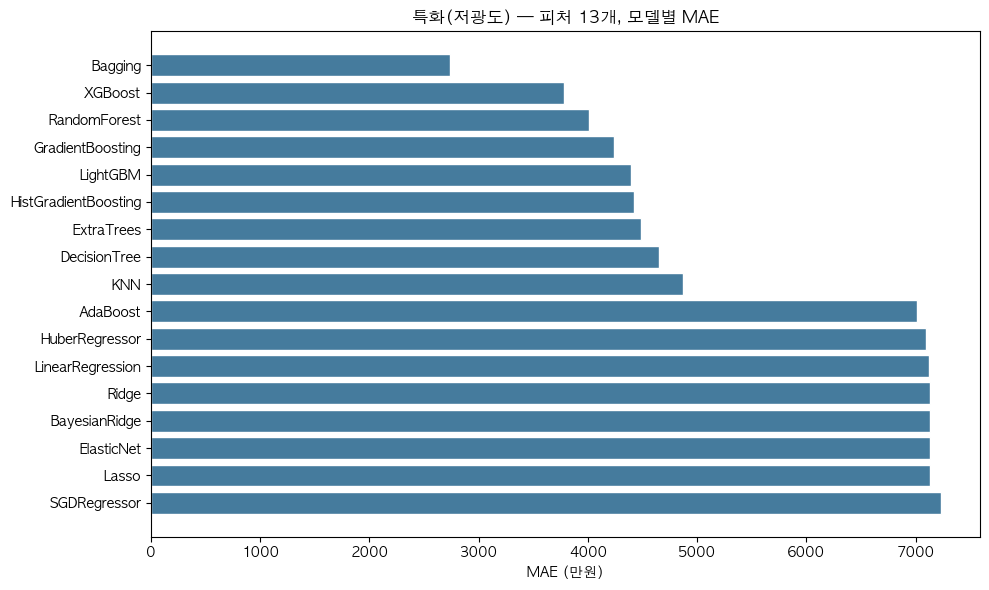

특화 1위: Bagging
MAE (저광도 test): 2,735 만원


In [8]:
plot_df = result_df.sort_values('MAE_만원', ascending=True)
plot_metrics_bars(
    plot_df, x_col='model',
    title=f'특화(저광도) — 피처 {len(feature_cols)}개, 모델별 4지표 (test)',
    colors='#457b9d',
)

best = result_df.iloc[0]
print(f"특화 1위: {best['model']}")
print(format_metric_line(best))


## 7. 1위 모델 하이퍼파라미터 tuning

In [9]:
from sklearn.model_selection import RandomizedSearchCV

best_name = result_df.iloc[0]['model']
mae_before = result_df.iloc[0]['MAE_만원']

print('=== tuning 대상 ===')
print(f'모델: {best_name}')
print('튜닝 전 (저광도 test):', format_metric_line(result_df.iloc[0]))


=== tuning 대상 ===
모델: Bagging
튜닝 전 MAE (저광도 test): 2,735 만원


In [10]:
tuning_table = {
    'HistGradientBoosting': (
        HistGradientBoostingRegressor(random_state=42), False,
        {
            'model__max_depth': [6, 8, 10, 12],
            'model__max_iter': [100, 200, 300],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__min_samples_leaf': [20, 50, 100],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 14, 18, None],
            'model__min_samples_leaf': [10, 20, 50],
            'model__max_features': ['sqrt', 0.5, 0.8],
        }
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 14, 18, None],
            'model__min_samples_leaf': [10, 20, 50],
        }
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=42), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [4, 6, 8],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__min_samples_leaf': [20, 50],
        }
    ),
    'DecisionTree': (
        DecisionTreeRegressor(random_state=42), False,
        {
            'model__max_depth': [8, 12, 16, 20],
            'model__min_samples_leaf': [10, 20, 50, 100],
        }
    ),
    'Ridge': (Ridge(), True, {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}),
    'Lasso': (Lasso(max_iter=5000), True, {'model__alpha': [0.0001, 0.001, 0.01, 0.1]}),
    'ElasticNet': (ElasticNet(max_iter=5000), True, {
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__l1_ratio': [0.2, 0.5, 0.8],
    }),
    'KNN': (KNeighborsRegressor(n_jobs=-1), True, {
        'model__n_neighbors': [5, 10, 15, 20, 30],
        'model__weights': ['uniform', 'distance'],
    }),
    'SVR_rbf': (SVR(), True, {
        'model__C': [0.1, 1.0, 10.0],
        'model__epsilon': [0.01, 0.1, 0.5],
        'model__gamma': ['scale', 'auto'],
    }),
    'AdaBoost': (
        AdaBoostRegressor(random_state=42), False,
        {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.05, 0.1, 0.5, 1.0],
        }
    ),
    'Bagging': (
        BaggingRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [20, 30, 50],
            'model__max_samples': [0.7, 0.9, 1.0],
        }
    ),
    'SGDRegressor': (
        SGDRegressor(max_iter=2000, tol=1e-3, random_state=42), True,
        {
            'model__alpha': [0.00001, 0.0001, 0.001, 0.01],
            'model__penalty': ['l2', 'elasticnet'],
        }
    ),
    'HuberRegressor': (
        HuberRegressor(max_iter=500), True,
        {
            'model__epsilon': [1.1, 1.35, 1.5],
            'model__alpha': [0.0001, 0.001, 0.01],
        }
    ),
    'BayesianRidge': (
        BayesianRidge(), True,
        {
            'model__alpha_1': [1e-6, 1e-5, 1e-4],
            'model__alpha_2': [1e-6, 1e-5, 1e-4],
        }
    ),
}

try:
    from xgboost import XGBRegressor
    tuning_table['XGBoost'] = (
        XGBRegressor(n_jobs=-1, random_state=42, verbosity=0), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [6, 8, 10],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__subsample': [0.7, 0.9, 1.0],
        }
    )
except ImportError:
    pass

try:
    from lightgbm import LGBMRegressor
    tuning_table['LightGBM'] = (
        LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [6, 8, 10],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__num_leaves': [31, 63, 127],
        }
    )
except ImportError:
    pass

if best_name not in tuning_table:
    if best_name == 'LinearRegression':
        print('LinearRegression — 튜닝 파라미터 없음 → Ridge로 tuning')
        best_name = 'Ridge'
    else:
        raise ValueError(f'{best_name} — tuning_table에 그리드 추가 필요')

base_model, use_scale, param_grid = tuning_table[best_name]

prep_steps = []
if feature_num:
    prep_steps.append(('num', StandardScaler() if use_scale else 'passthrough', feature_num))
if feature_cat:
    prep_steps.append(('cat', OneHotEncoder(handle_unknown='ignore'), feature_cat))

tune_pipe = Pipeline([
    ('prep', ColumnTransformer(prep_steps)),
    ('model', base_model),
])

print(f'탐색 조합 수: {np.prod([len(v) for v in param_grid.values()]):,.0f} (RandomizedSearchCV n_iter=20)')

탐색 조합 수: 9 (RandomizedSearchCV n_iter=20)


In [11]:
search = RandomizedSearchCV(
    tune_pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print(f'=== {best_name} tuning 시작 (저광도 train) ===')
t0 = time.time()
search.fit(X_train_low, y_train_low)
print(f'소요: {time.time() - t0:.0f}초')

print('\n최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

=== Bagging tuning 시작 (저광도 train) ===
Fitting 3 folds for each of 9 candidates, totalling 27 fits
소요: 51초

최적 파라미터:
  model__n_estimators: 50
  model__max_samples: 1.0


=== tuning 전후 (저광도 test) ===


,구분,MAE_만원,RMSE_만원,R2_log,MAE_개선_만원
0,튜닝 전 (기본),2735.0,5099.0,0.9428,NaN
1,튜닝 후 (최적),2706.0,5072.0,0.9441,29.0


MAE 2,735 → 2,706 만원  (+1.07%)


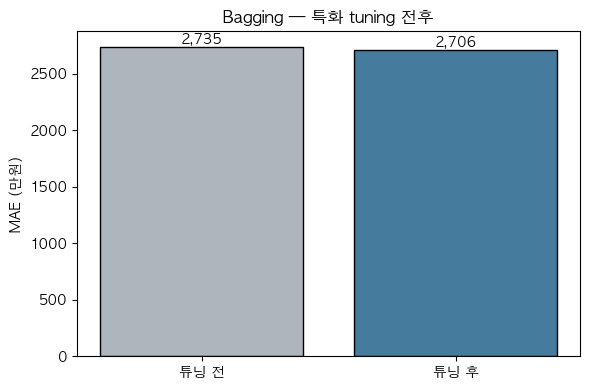

In [12]:
best_model = search.best_estimator_
pred_log = best_model.predict(X_test_low)
pred_won = np.expm1(pred_log)

mae_after = mean_absolute_error(y_won_test_low, pred_won)
rmse_after = np.sqrt(mean_squared_error(y_won_test_low, pred_won))
r2_after = r2_score(y_test_low, pred_log)

improve = mae_before - mae_after
pct = improve / mae_before * 100

compare = pd.DataFrame([
    {'구분': '튜닝 전 (기본)', 'MAE_만원': mae_before, 'RMSE_만원': result_df.iloc[0]['RMSE_만원'], 'R2_log': result_df.iloc[0]['R2_log']},
    {'구분': '튜닝 후 (최적)', 'MAE_만원': mae_after, 'RMSE_만원': rmse_after, 'R2_log': r2_after},
])
compare['MAE_개선_만원'] = [np.nan, improve]

print('=== tuning 전후 (저광도 test) ===')
display(compare.round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4, 'MAE_개선_만원': 0}))
print(f'MAE {mae_before:,.0f} → {mae_after:,.0f} 만원  ({pct:+.2f}%)')

labels = ['튜닝 전', '튜닝 후']
maes = [mae_before, mae_after]
colors = ['#adb5bd', '#457b9d']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, maes, color=colors, edgecolor='black')
for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width() / 2, val, f'{val:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylabel('MAE (만원)')
plt.title(f'{best_name} — 특화 tuning 전후')
plt.tight_layout()
plt.show()

## 8. 통합 vs 특화 MAE (저광도 test · Act 3-10)

=== 통합 모델 학습 (전체 train · 12_full과 동일 구조) ===
=== 저광도 test — 통합 vs 특화 ===


,모델,학습 데이터,MAE_만원,test,MAE_개선_만원
0,통합 (12_full),전체,2728.0,저광도,0.0
1,특화 (13),저광도만,2706.0,저광도,22.0


특화 MAE 개선: +22 만원 (+0.82%)


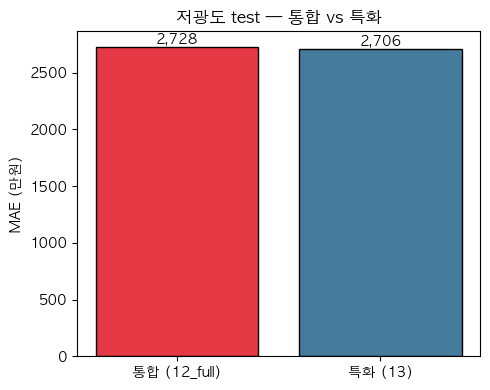

In [13]:
from sklearn.base import clone

# 10_fullbaseline과 동일 피처 (cluster_name 포함) — 통합 모델
full_feature_cols = [c for c in df.columns if c not in non_feature]
full_num = [c for c in full_feature_cols if pd.api.types.is_numeric_dtype(df[c])]
full_cat = [c for c in full_feature_cols if c not in full_num]

X_train_full = df.loc[X_train.index, full_feature_cols]
X_test_low_full = df.loc[X_test_low.index, full_feature_cols]

_, use_scale, _ = tuning_table[best_name]

prep_full = []
if full_num:
    prep_full.append(('num', StandardScaler() if use_scale else 'passthrough', full_num))
if full_cat:
    prep_full.append(('cat', OneHotEncoder(handle_unknown='ignore'), full_cat))

unified_pipe = Pipeline([
    ('prep', ColumnTransformer(prep_full)),
    ('model', clone(search.best_estimator_.named_steps['model'])),
])

print('=== 통합 모델 학습 (전체 train · 12_full과 동일 구조) ===')
unified_pipe.fit(X_train_full, y_train)
unified_pred = np.expm1(unified_pipe.predict(X_test_low_full))
mae_unified = mean_absolute_error(y_won_test_low, unified_pred)

mae_special = mae_after

vs = pd.DataFrame([
    {'모델': '통합 (12_full)', '학습 데이터': '전체', 'MAE_만원': mae_unified, 'test': '저광도'},
    {'모델': '특화 (13)', '학습 데이터': '저광도만', 'MAE_만원': mae_special, 'test': '저광도'},
])
vs['MAE_개선_만원'] = mae_unified - vs['MAE_만원']

print('=== 저광도 test — 통합 vs 특화 ===')
display(vs.round({'MAE_만원': 0, 'MAE_개선_만원': 0}))

diff = mae_unified - mae_special
print(f'특화 MAE 개선: {diff:+,.0f} 만원 ({diff / mae_unified * 100:+.2f}%)')

plt.figure(figsize=(5, 4))
plt.bar(vs['모델'], vs['MAE_만원'], color=['#e63946', '#457b9d'], edgecolor='black')
plt.ylabel('MAE (만원)')
plt.title('저광도 test — 통합 vs 특화')
for i, v in enumerate(vs['MAE_만원']):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 풀 데이터셋 재학습 (튜닝 Bagging · 저광도)

7번 `search.best_estimator_`로 **저광도 train 전체** 학습 · 통합 vs 특화 **4지표** 비교 + 2×2 시각화

풀 데이터: 2,396,830건 (샘플링 없음)
저광도 train: 1,002,436 / test: 250,923
특화 학습 소요: 98초
사용 파라미터: {'model__n_estimators': 50, 'model__max_samples': 1.0}

=== 특화 모델 — 저광도 test 4지표 (풀) ===


,MAE_만원,RMSE_만원,R2_log,MAPE_pct
0,1548.0,2922.0,0.9757,7.6



=== 통합 모델 학습 (전체 train · 풀) ===
통합 학습 소요: 598초
=== 저광도 test — 통합 vs 특화 4지표 (풀) ===


,모델,MAE_만원,RMSE_만원,R2_log,MAPE_pct,MAE_만원_개선,RMSE_만원_개선,MAPE_pct_개선
0,통합 (12_full),1558.0,2936.0,0.9753,7.6,0.0,0.0,0.0
1,특화 (13),1548.0,2922.0,0.9757,7.6,10.0,14.0,0.1


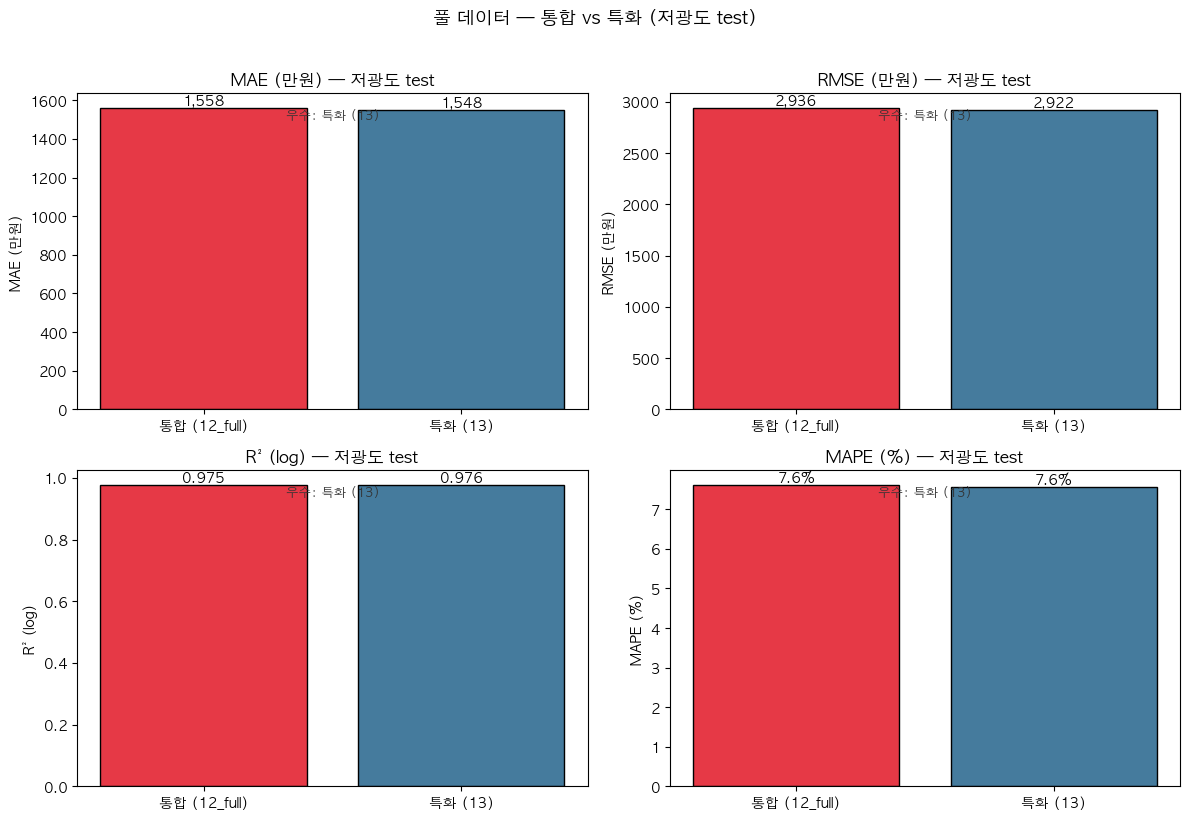

In [14]:
from sklearn.base import clone

def _eval_4(actual, pred_log, y_log):
    pred_won = np.expm1(pred_log)
    return {
        'MAE_만원': mean_absolute_error(actual, pred_won),
        'RMSE_만원': np.sqrt(mean_squared_error(actual, pred_won)),
        'R2_log': r2_score(y_log, pred_log),
        'MAPE_pct': (np.abs(actual - pred_won) / np.clip(actual, 1, None)).mean() * 100,
    }

df_full = pd.read_csv('apt_ml_ready.csv', encoding='utf-8-sig')
print(f'풀 데이터: {len(df_full):,}건 (샘플링 없음)')

X_all = df_full[feature_cols]
y_log_all = df_full['log_dealAmount_num']
y_won_all = df_full['dealAmount_num']

X_tr, X_te, y_tr, y_te, y_won_tr, y_won_te = train_test_split(
    X_all, y_log_all, y_won_all, test_size=0.2, random_state=42,
)

low_tr = df_full.loc[X_tr.index, 'cluster_name'] == '저광도'
low_te = df_full.loc[X_te.index, 'cluster_name'] == '저광도'

X_tr_low = X_tr.loc[low_tr]
y_tr_low = y_tr.loc[low_tr]
X_te_low = X_te.loc[low_te]
y_te_low = y_te.loc[low_te]
y_won_te_low = y_won_te.loc[low_te]
actual_low = y_won_te_low.values

print(f'저광도 train: {len(X_tr_low):,} / test: {len(X_te_low):,}')

t0 = time.time()
full_special = clone(search.best_estimator_)
full_special.fit(X_tr_low, y_tr_low)
print(f'특화 학습 소요: {time.time() - t0:.0f}초')
print('사용 파라미터:', search.best_params_)

pred_log_sp = full_special.predict(X_te_low)
metrics_special = _eval_4(actual_low, pred_log_sp, y_te_low.values)

print('\n=== 특화 모델 — 저광도 test 4지표 (풀) ===')
display(pd.DataFrame([metrics_special]).round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4, 'MAPE_pct': 1}))

# 통합 모델 (10_fullbaseline 14피처)
full_feature_cols = [c for c in df_full.columns if c not in non_feature]
full_num = [c for c in full_feature_cols if pd.api.types.is_numeric_dtype(df_full[c])]
full_cat = [c for c in full_feature_cols if c not in full_num]

_, use_scale, _ = tuning_table[best_name]
prep_full = []
if full_num:
    prep_full.append(('num', StandardScaler() if use_scale else 'passthrough', full_num))
if full_cat:
    prep_full.append(('cat', OneHotEncoder(handle_unknown='ignore'), full_cat))

unified_pipe = Pipeline([
    ('prep', ColumnTransformer(prep_full)),
    ('model', clone(search.best_estimator_.named_steps['model'])),
])

print('\n=== 통합 모델 학습 (전체 train · 풀) ===')
t1 = time.time()
unified_pipe.fit(df_full.loc[X_tr.index, full_feature_cols], y_tr)
print(f'통합 학습 소요: {time.time() - t1:.0f}초')

pred_log_un = unified_pipe.predict(df_full.loc[X_te_low.index, full_feature_cols])
metrics_unified = _eval_4(actual_low, pred_log_un, y_te_low.values)

vs = pd.DataFrame([
    {'모델': '통합 (12_full)', **metrics_unified},
    {'모델': '특화 (13)', **metrics_special},
])
for col in ['MAE_만원', 'RMSE_만원', 'MAPE_pct']:
    vs[f'{col}_개선'] = metrics_unified[col] - vs[col]

print('=== 저광도 test — 통합 vs 특화 4지표 (풀) ===')
display(vs.round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4, 'MAPE_pct': 1,
                  'MAE_만원_개선': 0, 'RMSE_만원_개선': 0, 'MAPE_pct_개선': 1}))

metric_plot = [
    ('MAE_만원', 'MAE (만원)', '{:,.0f}', 'lower'),
    ('RMSE_만원', 'RMSE (만원)', '{:,.0f}', 'lower'),
    ('R2_log', 'R² (log)', '{:.3f}', 'higher'),
    ('MAPE_pct', 'MAPE (%)', '{:.1f}%', 'lower'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
bar_colors = ['#e63946', '#457b9d']
for ax, (col, ylabel, fmt, better) in zip(axes.ravel(), metric_plot):
    vals = vs[col].values
    ax.bar(vs['모델'], vals, color=bar_colors, edgecolor='black')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — 저광도 test')
    for i, v in enumerate(vals):
        ax.text(i, v, fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    winner = vs.loc[vals.argmin() if better == 'lower' else vals.argmax(), '모델']
    ax.text(0.5, 0.95, f'우수: {winner}', transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='#333')

plt.suptitle('풀 데이터 — 통합 vs 특화 (저광도 test)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()